# Deep Learning Primitives and Shallow Networks

You are part of a research team tasked with migrating traditional NLP methods (like N-Grams) to modern neural network architectures. Before building complex models like RNNs, you must first master the fundamental mathematical components that allow any deep learning model to learn.

Your primary goal is to implement and visualize the key functions (Activation, Loss, Optimization) and then integrate them into a simple, fully-connected (shallow) network using a modern framework (PyTorch).


## Import required libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt


## Tasks

### Task 1: Activation Function Implementation (Sigmoid)
The activation function is crucial for introducing non-linearity into the network, allowing it to learn complex patterns.
Implement the `sigmoid(x)` function using numpy:

 - Generate input values  from -10 to 10 and calculate the corresponding Sigmoid output.
 - Plot the Sigmoid Activation Function using matplotlib to visualize its non-linear S-shape and saturation behavior.

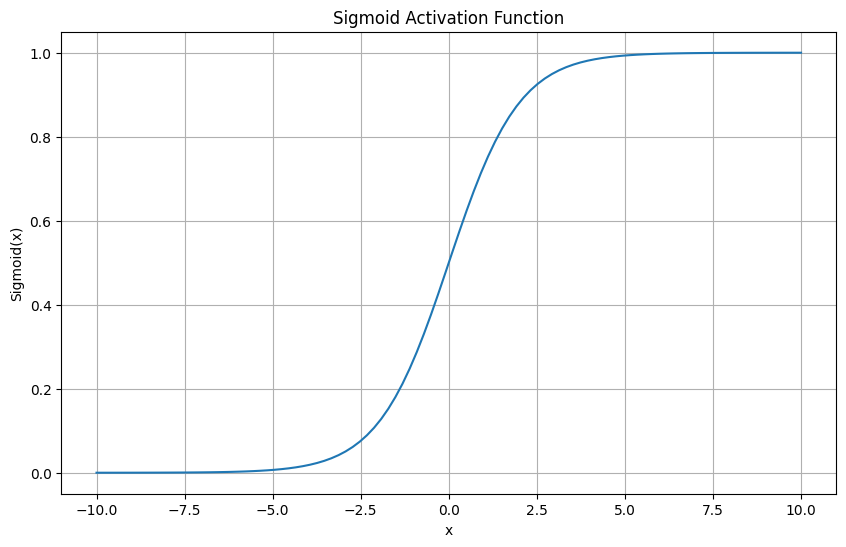

In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 100)
y_sigmoid = sigmoid(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y_sigmoid)
plt.title('Sigmoid Activation Function')
plt.xlabel('x')
plt.ylabel('Sigmoid(x)')
plt.grid(True)
plt.show()

### Task 2: Loss Function Definition (Mean Squared Error)
The loss function quantifies the difference between the model's prediction and the true value.
 - Define the loss function `def loss_function(x)`, which is $ y = x^2$
 - Deinfe the Gradiant function `def gradiant(x)`, which is $ y = 2x $

 - Implement and Visualise the Gradient Descent Algorithm Implement a generic `gradient_descent(loss_function, gradient, start_x, learning_rate, iterations)` function.
 - Use the provided `loss_function(x)` function and its gradient to simulate the iterative update process.
 - Run the optimizer for a set number of iterations (e.g., 100), printing the x value, Loss, and Gradient at each step to demonstrate convergence to the minimum.


#### Import Required Libraries

In [5]:
import numpy as np
import matplotlib.pyplot as plt

#### Define Loss Function and Gradient

In [7]:
# Define a simple quadratic loss function: y = x^2
def loss_function(x):
    return x**2

# Derivative of the loss function: dy/dx = 2x
def gradient(x):
    return 2*x

#### Gardient Descent Formulae: new = old - learning rate * slope


#### Gradient Descent Algorithm

In [8]:
# Gradient Descent Algorithm
def gradient_descent(starting_point, learning_rate, iterations):
  x = starting_point  # Initial value
  history = []        # To store x values and corresponding loss

  for i in range(1, iterations + 1):
    loss = loss_function(x)
    grad = gradient(x)
    history.append((x, loss))

    print(f"Iteration {i}: x = {x:.4f}, Loss = {loss:.4f}, Gradient = {grad:.4f}")

    # Update x using gradient descent formula
    x = x - learning_rate * grad

  return history

#### Parameters for Gradient Descent

In [9]:
starting_point = 10  # Starting point for x
learning_rate = 0.08 # Step size for gradient descent
iterations = 300      # Number of iterations

#### Run Gradient Descent

In [10]:
history = gradient_descent(starting_point, learning_rate, iterations)

Iteration 1: x = 10.0000, Loss = 100.0000, Gradient = 20.0000
Iteration 2: x = 8.4000, Loss = 70.5600, Gradient = 16.8000
Iteration 3: x = 7.0560, Loss = 49.7871, Gradient = 14.1120
Iteration 4: x = 5.9270, Loss = 35.1298, Gradient = 11.8541
Iteration 5: x = 4.9787, Loss = 24.7876, Gradient = 9.9574
Iteration 6: x = 4.1821, Loss = 17.4901, Gradient = 8.3642
Iteration 7: x = 3.5130, Loss = 12.3410, Gradient = 7.0260
Iteration 8: x = 2.9509, Loss = 8.7078, Gradient = 5.9018
Iteration 9: x = 2.4788, Loss = 6.1442, Gradient = 4.9575
Iteration 10: x = 2.0822, Loss = 4.3354, Gradient = 4.1643
Iteration 11: x = 1.7490, Loss = 3.0590, Gradient = 3.4980
Iteration 12: x = 1.4692, Loss = 2.1585, Gradient = 2.9383
Iteration 13: x = 1.2341, Loss = 1.5230, Gradient = 2.4682
Iteration 14: x = 1.0366, Loss = 1.0746, Gradient = 2.0733
Iteration 15: x = 0.8708, Loss = 0.7583, Gradient = 1.7416
Iteration 16: x = 0.7315, Loss = 0.5350, Gradient = 1.4629
Iteration 17: x = 0.6144, Loss = 0.3775, Gradient = 

#### Visualization of Gradient Descent

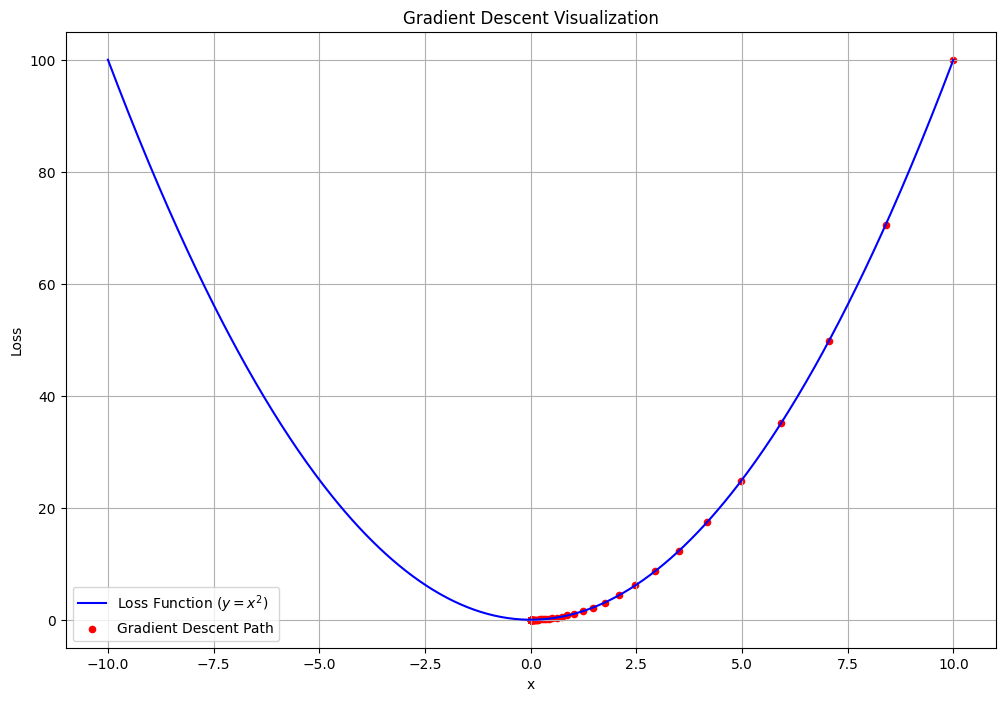

In [12]:
# Extract x and loss values for plotting
x_history = [item[0] for item in history]
loss_history = [item[1] for item in history]

# Plotting the Loss Function
x_plot = np.linspace(-10, 10, 500)
y_plot = loss_function(x_plot)

plt.figure(figsize=(12, 8))
plt.plot(x_plot, y_plot, label='Loss Function ($y=x^2$)', color='blue')
plt.scatter(x_history, loss_history, color='red', s=20, label='Gradient Descent Path')

plt.title('Gradient Descent Visualization')
plt.xlabel('x')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

### Task 3: Building a Shallow DNN in PyTorch
Translate the mathematical primitives into a functional PyTorch model.

![image](https://matthewmazur.files.wordpress.com/2018/03/neural_network-9.png)

Define a class SimpleDNN that inherits from torch.nn.Module.
Construct a simple network with two layers:
- An input layer  a hidden layer (e.g., 2 input features, 2 hidden units).
- A hidden layer  an output layer (e.g., 2 hidden units, 1 output unit).
- Use the Sigmoid activation function on the output layer to ensure the output is between 0 and 1, suitable for binary classification probability.
- Write the forward() method and test it with a sample input tensor (e.g., torch.Tensor([0.05, 0.10])).



- [Source_blog](https://mattmazur.com/2015/03/17/a-step-by-step-backpropagation-example/)

In [13]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy
from sklearn import datasets

In [14]:
m = nn.Linear(20, 30)

In [15]:
nn.Linear

torch.nn.modules.linear.Linear

In [16]:
m = nn.Linear(2, 3)
input = torch.randn(3, 2)
output = m(input)


In [17]:
input

tensor([[ 0.7445,  0.6186],
        [-0.1400, -1.6918],
        [ 0.4247, -0.0280]])

In [18]:
output

tensor([[-0.1785, -0.4615,  0.8297],
        [-0.6939,  0.2697, -0.0514],
        [-0.3343, -0.2503,  0.5588]], grad_fn=<AddmmBackward0>)

In [19]:
output.shape

torch.Size([3, 3])

In [20]:
m.weight.data

tensor([[ 0.1591,  0.1622],
        [-0.0897, -0.2821],
        [ 0.3358,  0.2528]])

In [21]:
m.bias.data

tensor([-0.3973, -0.2201,  0.4233])

In [22]:
def init_weight(m):
    if type(m) in [nn.Conv2d,nn.Linear]:
        m.weight.data=torch.Tensor([[0.15,0.20],[0.25,0.30]])
        m.bias.data=torch.Tensor([0.35])

In [23]:
## Model Set Up
class Perceptron(nn.Module):
  def __init__(self,input_size,H1,output_size):
      super().__init__()
      self.W1 = nn.Parameter(torch.tensor([[0.15, 0.20], [0.25, 0.30]]))
      self.b1 = nn.Parameter(torch.tensor([0.35, 0.35]))
      self.W2 = nn.Parameter(torch.tensor([[0.40, 0.45], [0.50, 0.55]]))
      self.b2 = nn.Parameter(torch.tensor([0.60, 0.60]))

      self.sigmoid = nn.Sigmoid()

  def forward(self,x, print_values=True):
      original_x_dim = x.dim()
      if original_x_dim == 1:
          x = x.unsqueeze(0)

      net_h = torch.matmul(x, self.W1.T) + self.b1
      out_h = self.sigmoid(net_h)
      net_O = torch.matmul(out_h, self.W2.T) + self.b2
      out_O = self.sigmoid(net_O)

      if print_values:
          print(f"h1: {net_h[0][0].item()}, h2: {net_h[0][1].item()}")
          print(f"out_h1: {out_h[0][0].item()}, out_h2: {out_h[0][1].item()}")
          print(f"net_O1: {net_O[0][0].item()}, net_O2: {net_O[0][1].item()}")
          print(f"out_O1: {out_O[0][0].item()}, out_O2: {out_O[0][1].item()}")

      if original_x_dim == 1:
          return out_O.squeeze(0)
      return out_O

## Unfold each epoch and check intermediate values


### Initial Weight of the model

In [24]:
model=Perceptron(2,2,1)
print (list(model.parameters()))

[Parameter containing:
tensor([[0.1500, 0.2000],
        [0.2500, 0.3000]], requires_grad=True), Parameter containing:
tensor([0.3500, 0.3500], requires_grad=True), Parameter containing:
tensor([[0.4000, 0.4500],
        [0.5000, 0.5500]], requires_grad=True), Parameter containing:
tensor([0.6000, 0.6000], requires_grad=True)]


### After 1 forward pass check hidden, output and loss

![image](https://matthewmazur.files.wordpress.com/2018/03/neural_network-9.png)

In [25]:
model.forward(torch.Tensor([0.05,0.10]))

h1: 0.3774999976158142, h2: 0.39249998331069946
out_h1: 0.5932700037956238, out_h2: 0.5968843698501587
net_O1: 1.1059060096740723, net_O2: 1.224921464920044
out_O1: 0.751365065574646, out_O2: 0.7729284763336182


tensor([0.7514, 0.7729], grad_fn=<SqueezeBackward1>)

$$\ell(x, y) = L = \{l_1,\dots,l_N\}^\top, \quad l_n = \left( x_n - y_n \right)^2,$$

In [26]:
nn.MSELoss

torch.nn.modules.loss.MSELoss

In [27]:
model=Perceptron(2,2,2)
criterion=nn.MSELoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.5)
output=model.forward(torch.Tensor([0.05,0.10]))
target=torch.Tensor([0.01,0.99])
loss=criterion(output,target)
print("total MSEerror: {}".format(loss.item()))

h1: 0.3774999976158142, h2: 0.39249998331069946
out_h1: 0.5932700037956238, out_h2: 0.5968843698501587
net_O1: 1.1059060096740723, net_O2: 1.224921464920044
out_O1: 0.751365065574646, out_O2: 0.7729284763336182
total MSEerror: 0.2983711063861847


### Backward pass

In [28]:
# set prev grad to zero
optimizer.zero_grad()

loss.backward()

optimizer.step()

print(list(model.parameters()))

[Parameter containing:
tensor([[0.1498, 0.1996],
        [0.2498, 0.2995]], requires_grad=True), Parameter containing:
tensor([0.3456, 0.3450], requires_grad=True), Parameter containing:
tensor([[0.3589, 0.4087],
        [0.5113, 0.5614]], requires_grad=True), Parameter containing:
tensor([0.5308, 0.6190], requires_grad=True)]


### 2nd Forward Pass

In [29]:
y_output = model.forward(torch.Tensor([0.05,0.10]))

h1: 0.37305948138237, h2: 0.3874606490135193
out_h1: 0.5921980738639832, out_h2: 0.5956712365150452
net_O1: 0.9867310523986816, net_O2: 1.256232738494873
out_O1: 0.7284417748451233, out_O2: 0.7783768773078918


### 2nd Backward pass

In [30]:
loss=criterion(y_output,target)

optimizer.zero_grad()

loss.backward()

optimizer.step()

print(list(model.parameters()))

[Parameter containing:
tensor([[0.1496, 0.1992],
        [0.2495, 0.2990]], requires_grad=True), Parameter containing:
tensor([0.3417, 0.3405], requires_grad=True), Parameter containing:
tensor([[0.3168, 0.3663],
        [0.5221, 0.5722]], requires_grad=True), Parameter containing:
tensor([0.4597, 0.6373], requires_grad=True)]


## Reinitializing the model and looping over Epoch

In [31]:
model=Perceptron(2,2,2)
criterion=nn.MSELoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.5)

input_x = torch.Tensor([0.05,0.10])
epoch = 200
for i in range(epoch):
    # Forward Pass
    y_output = model.forward(input_x, print_values=False)
    loss = criterion(y_output, target)

    # Backward Pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i%10 == 0:
        print(f'Epoch: {i}, loss: {loss.item()}, output: {y_output}')
        print("="*60)

Epoch: 0, loss: 0.2983711063861847, output: tensor([0.7514, 0.7729], grad_fn=<SqueezeBackward1>)
Epoch: 10, loss: 0.1255270540714264, output: tensor([0.4800, 0.8164], grad_fn=<SqueezeBackward1>)
Epoch: 20, loss: 0.052938103675842285, output: tensor([0.3012, 0.8448], grad_fn=<SqueezeBackward1>)
Epoch: 30, loss: 0.030056718736886978, output: tensor([0.2205, 0.8643], grad_fn=<SqueezeBackward1>)
Epoch: 40, loss: 0.02027370221912861, output: tensor([0.1777, 0.8785], grad_fn=<SqueezeBackward1>)
Epoch: 50, loss: 0.015036690980196, output: tensor([0.1512, 0.8893], grad_fn=<SqueezeBackward1>)
Epoch: 60, loss: 0.011820781975984573, output: tensor([0.1330, 0.8978], grad_fn=<SqueezeBackward1>)
Epoch: 70, loss: 0.009662418626248837, output: tensor([0.1198, 0.9047], grad_fn=<SqueezeBackward1>)
Epoch: 80, loss: 0.008121891878545284, output: tensor([0.1096, 0.9104], grad_fn=<SqueezeBackward1>)
Epoch: 90, loss: 0.006971747614443302, output: tensor([0.1015, 0.9153], grad_fn=<SqueezeBackward1>)
Epoch: 10

**Note:** at Line 3 above, if we use `Adam` optimizer, it will learn faster in lesser epoch. For example, with Adam, only using 10 epochs, the model will learn the optimum weight

In [32]:
print(list(model.parameters()))

[Parameter containing:
tensor([[0.1632, 0.2264],
        [0.2625, 0.3249]], requires_grad=True), Parameter containing:
tensor([0.6137, 0.5991], requires_grad=True), Parameter containing:
tensor([[-0.9046, -0.8579],
        [ 1.0152,  1.0661]], requires_grad=True), Parameter containing:
tensor([-1.5563,  1.4385], requires_grad=True)]


## Prediction

In [33]:
print (model.forward(torch.Tensor([0.06,0.12])))

h1: 0.6506630778312683, h2: 0.6538770198822021
out_h1: 0.6571599245071411, out_h2: 0.6578835844993591
net_O1: -2.7151784896850586, net_O2: 2.8070878982543945
out_O1: 0.06208362430334091, out_O2: 0.943057656288147
tensor([0.0621, 0.9431], grad_fn=<SqueezeBackward1>)
